In [17]:
from astropy.io import fits
from scipy.io import readsav
from scipy.stats import gaussian_kde
import numpy as np
import pandas as pd
import os
import copy

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

import tools as t

In [2]:
# Parameters

N = 3686
M = 20
TS = 1

# Load data

X = []
y = []

for i in range(N):

    data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')

    X.append(data['scores'].float())
    y.append(torch.as_tensor(data['rv'], dtype=torch.float32))

X = torch.stack(X)
y = torch.stack(y).reshape(-1, 1)

print("Total X shape:", X.shape)
print("Total y shape:", y.shape)

/tmp/ipykernel_1950998/1897771005.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  data = torch.load(f'../data/PCA/TS{TS}/t_{i}.pt')


Total X shape: torch.Size([3686, 20])
Total y shape: torch.Size([3686, 1])


In [3]:
# RV stats
print(f'Mean: {y.mean().item()}')
print(f'Sigma: {y.std().item()}')
print(f'Min: {y.min().item()}')
print(f'Max: {y.max().item()}')

Mean: -3.8809319646837537e-10
Sigma: 0.9465776681900024
Min: -3.7014224529266357
Max: 3.3682401180267334


In [4]:
batch_size = 32

# Chronological train/test split

train_size = int(0.7 * N)
val_size = int(0.1 * N)

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

#print(X_train.mean(dim=0))
#print(X_train.std(dim=0))

#print(((X_train - X_train.mean(dim=0)) / X_train.std(dim=0)).std(dim=0))

print("Train X shape:", X_train.shape)
print("Train y shape:", y_train.shape)

print("Validation X shape:", X_val.shape)
print("Validation y shape:", y_val.shape)

print("Test X shape:", X_test.shape)
print("Test y shape:", y_test.shape)

# Scaling scores
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train.numpy())
X_val_scaled = scaler.transform(X_val.numpy())
X_test_scaled = scaler.transform(X_test.numpy())

X_train = torch.tensor(X_train_scaled, dtype=torch.float32)
X_val = torch.tensor(X_val_scaled, dtype=torch.float32)
X_test = torch.tensor(X_test_scaled, dtype=torch.float32)

# Create Datasets
# Pair the rows of X with the corresponding rows of y

train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# Create DataLoaders
# takes a Dataset and gives samples to the model in batches

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True  # The model sees the same 80% of the data, but in a different order each epoch
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False  # There's no benefit to shuffling it because we're not updating the model during testing
)

Train X shape: torch.Size([2580, 20])
Train y shape: torch.Size([2580, 1])
Validation X shape: torch.Size([368, 20])
Validation y shape: torch.Size([368, 1])
Test X shape: torch.Size([738, 20])
Test y shape: torch.Size([738, 1])


In [5]:
# Model
# M = 20 PCs
model = nn.Sequential(
    nn.Linear(M, 32),
    nn.ReLU(),
    # BN
    nn.Linear(32, 16),
    nn.ReLU(),
    # BN
    nn.Linear(16, 1)
)

# Loss and optimizer
criterion = nn.MSELoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=0
)

# Scheduler: if validation loss stops improving, PyTorch reduces the learning rate
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=20
)

# Early stopping parameters
patience = 50
best_val_loss = float("inf")
epochs_without_improvement = 0

# Store the parameters of the best model
best_model_state = copy.deepcopy(model.state_dict())

# Training
epochs = 1000
loss_history = []
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward pass
        y_pred = model(X_batch)

        # Calculate loss
        loss = criterion(y_pred, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    # Average loss over batches
    train_loss /= len(train_loader)
    loss_history.append(train_loss)  # save

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            y_pred = model(X_batch)
            loss = criterion(y_pred, y_batch)
            val_loss += loss.item()
    # Average validation loss
    val_loss /= len(val_loader)

    # Early stopping
    if val_loss < best_val_loss:
        # Validation loss improved
        best_val_loss = val_loss
        epochs_without_improvement = 0
        # Save best model
        best_model_state = copy.deepcopy(model.state_dict())

    else:
        # No improvement
        epochs_without_improvement += 1

    # Print progress
    if epoch % (epochs // 10) == 0 or epoch == epochs - 1:
        print(
            f"Epoch {epoch}: "
            f"train loss = {train_loss:.4f}, "
            f"val loss = {val_loss:.4f}"
        )

    # Stop if validation loss hasn't improved
    if epochs_without_improvement >= patience:
        print(
            f"\nEarly stopping at epoch {epoch}. "
        )
        break

    # Scheduler
    scheduler.step(val_loss)
    
# Restore best model
model.load_state_dict(best_model_state)
print(f"Best validation loss: {best_val_loss:.4f}")

Epoch 0: train loss = 0.9771, val loss = 0.6346
Epoch 100: train loss = 0.0273, val loss = 0.0364

Early stopping at epoch 157. 
Best validation loss: 0.0363


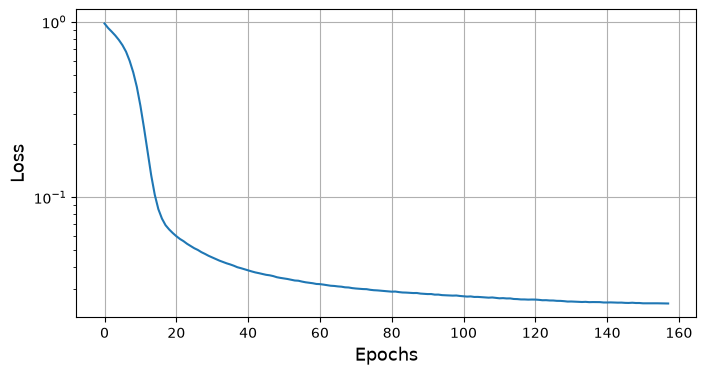

In [6]:
# plot loss history (from training)

fig, ax = plt.subplots(figsize=(8, 4))
ax.grid()
ax.plot(loss_history)
ax.set_xlabel('Epochs', size=13)
ax.set_ylabel('Loss', size=13)
ax.set_yscale('log')

plt.show()

In [7]:
# Function to evaluate a dataset
def evaluate_model(data_loader):
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            y_pred = model(X_batch)

            all_predictions.append(y_pred)
            all_targets.append(y_batch)

    # Combine all batches
    y_pred = torch.cat(all_predictions).squeeze().numpy()
    y_true = torch.cat(all_targets).squeeze().numpy()

    # Metrics
    mse = np.mean((y_pred - y_true) ** 2)
    mae = np.mean(np.abs(y_pred - y_true))
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    return y_true, y_pred, mse, mae, rmse, r2

In [8]:
# Testing
model.eval()

# Evaluate training set
y_train_true, y_train_pred, train_mse, train_mae, train_rmse, train_r2 = evaluate_model(train_loader)

# Evaluate validation set
y_val_true, y_val_pred, val_mse, val_mae, val_rmse, val_r2 = evaluate_model(val_loader)

# Evaluate testing set
y_test_true, y_test_pred, test_mse, test_mae, test_rmse, test_r2 = evaluate_model(test_loader)

# Print results
print(f'Train MSE: {train_mse:.4f}')
print(f'Validation MSE: {val_mse:.4f}')
print(f'Test MSE: {test_mse:.4f}')

Train MSE: 0.0265
Validation MSE: 0.0350
Test MSE: 0.0359


In [9]:
def plot_true_vs_pred(true, pred, ax, color):
    ax.scatter(true, pred, alpha=0.6, label='Model results', color=color)

    # Perfect-prediction line
    min_val = min(true.min(), pred.min())
    max_val = max(true.max(), pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], '--', color='k', label='Ideal case')

    ax.set_xlabel('True RV [m/s]', size=13)
    ax.set_ylabel('Predicted RV [m/s]', size=13)
    ax.grid(True)
    #ax.axis('equal')
    ax.legend()

Standard deviation of the predicted RVs: 0.9413185715675354
Standard deviation of the test RVs: 0.9773247241973877


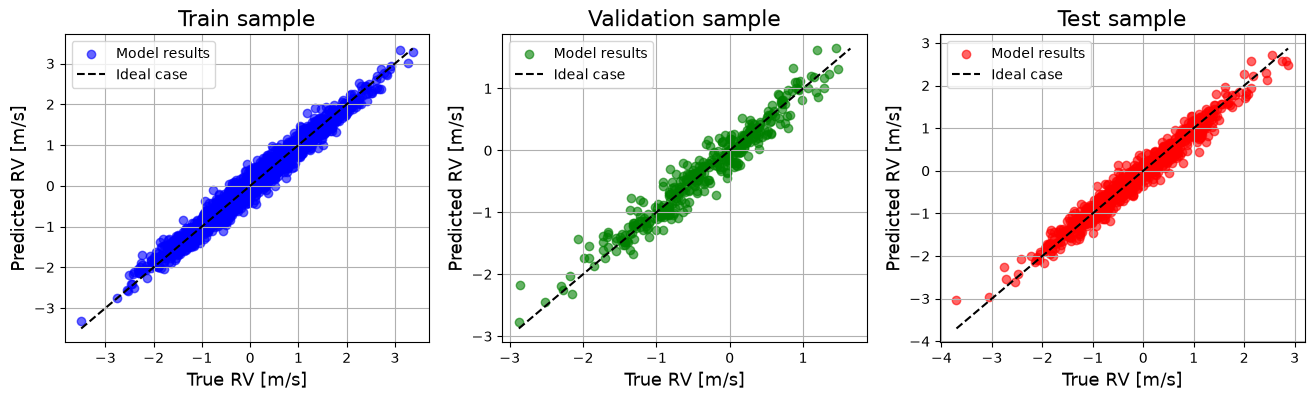

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(16, 4))

plot_true_vs_pred(y_train_true, y_train_pred, axs[0], 'blue')
plot_true_vs_pred(y_val_true, y_val_pred, axs[1], 'green')
plot_true_vs_pred(y_test_true, y_test_pred, axs[2], 'red')

axs[0].set_title('Train sample', size=16)
axs[1].set_title('Validation sample', size=16)
axs[2].set_title('Test sample', size=16)

print(f'Standard deviation of the predicted RVs: {y_test_pred.std()}')
print(f'Standard deviation of the test RVs: {y_test.std()}')

In [11]:
data_train = {
    'y_train_true': y_train_true,
    'y_train_pred': y_train_pred,
}

data_val = {
    'y_val_true': y_val_true,
    'y_val_pred': y_val_pred,
}

data_test = {
    'y_test_true': y_test_true,
    'y_test_pred': y_test_pred
}

df_train = pd.DataFrame(data=data_train)
df_val = pd.DataFrame(data=data_val)
df_test = pd.DataFrame(data=data_test)

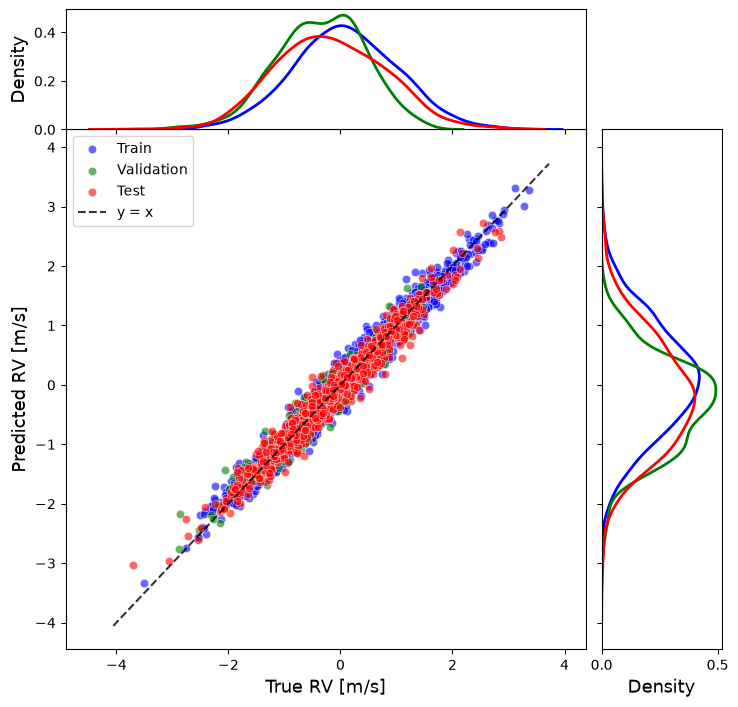

In [12]:
# Superposed

fig = plt.figure(figsize=(8, 8))

# Main scatter plot
ax = fig.add_axes([0.12, 0.12, 0.65, 0.65])

sns.scatterplot(
    data=df_train,
    x='y_train_true',
    y='y_train_pred',
    color='blue',
    alpha=.6,
    label='Train',
    ax=ax
)

sns.scatterplot(
    data=df_val,
    x='y_val_true',
    y='y_val_pred',
    color='green',
    alpha=.6,
    label='Validation',
    ax=ax
)

sns.scatterplot(
    data=df_test,
    x='y_test_true',
    y='y_test_pred',
    color='red',
    alpha=.6,
    label='Test',
    ax=ax
)

# Reference line y = x
lims = ax.get_xlim()
ax.plot(lims, lims, '--', color='black', alpha=0.8, label='y = x')

ax.set_xlabel('True RV [m/s]', size=13)
ax.set_ylabel('Predicted RV [m/s]', size=13)
ax.legend()


# ---- Smooth marginal distributions ----

# Top: distributions of TRUE values
ax_top = fig.add_axes([0.12, 0.77, 0.65, 0.15], sharex=ax)

sns.kdeplot(
    data=df_train,
    x='y_train_true',
    color='blue',
    linewidth=2,
    ax=ax_top,
    label='Train'
)

sns.kdeplot(
    data=df_val,
    x='y_val_true',
    color='green',
    linewidth=2,
    ax=ax_top,
    label='Validation'
)

sns.kdeplot(
    data=df_test,
    x='y_test_true',
    color='red',
    linewidth=2,
    ax=ax_top,
    label='Test'
)

ax_top.set_ylabel('Density', size=13)
ax_top.set_xlabel('')
ax_top.tick_params(axis='x', labelbottom=False)


# Right: distributions of PREDICTED values
ax_right = fig.add_axes([0.79, 0.12, 0.15, 0.65], sharey=ax)

sns.kdeplot(
    data=df_train,
    y='y_train_pred',
    color='blue',
    linewidth=2,
    ax=ax_right,
    label='Train'
)

sns.kdeplot(
    data=df_val,
    y='y_val_pred',
    color='green',
    linewidth=2,
    ax=ax_right,
    label='Validation'
)

sns.kdeplot(
    data=df_test,
    y='y_test_pred',
    color='red',
    linewidth=2,
    ax=ax_right,
    label='Test'
)

ax_right.set_xlabel('Density', size=13)
ax_right.set_ylabel('')
ax_right.tick_params(axis='y', labelleft=False)

plt.show()

In [13]:
# true - predicted for each sample
diff_train = y_train_true - y_train_pred
diff_val = y_val_true - y_val_pred
diff_test = y_test_true - y_test_pred

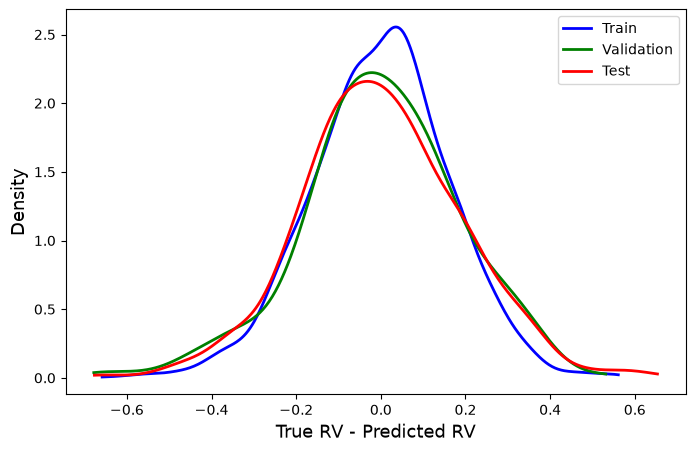

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

#ax.hist(diff_train, alpha=.5, density=True)
#ax.hist(diff_val, alpha=.5, density=True)
#ax.hist(diff_test, alpha=.5, density=True)

# Smooth KDE curve
kde_train = gaussian_kde(diff_train)
x_train = np.linspace(diff_train.min(), diff_train.max(), 500)

kde_val = gaussian_kde(diff_val)
x_val = np.linspace(diff_val.min(), diff_val.max(), 500)

kde_test = gaussian_kde(diff_test)
x_test = np.linspace(diff_test.min(), diff_test.max(), 500)

# Density histograms
ax.plot(x_train, kde_train(x_train), linewidth=2, color='blue', label='Train')
ax.plot(x_val, kde_val(x_val), linewidth=2, color='green', label='Validation')
ax.plot(x_test, kde_test(x_test), linewidth=2, color='red', label='Test')

ax.set_xlabel('True RV - Predicted RV', size=13)
ax.set_ylabel('Density', size=13)
ax.legend()

plt.show()

In [34]:
print('---------- Mean of True RV - Predicted RV ----------')
print(f'Train: {np.mean(diff_train):.5f}')
print(f'Validation: {np.mean(diff_val):.5f}')
print(f'Test: {np.mean(diff_test):.5f}')

print('---------- Std of True RV - Predicted RV ----------')
print(f'Train: {np.std(diff_train):.4f}')
print(f'Validation: {np.std(diff_val):.4f}')
print(f'Test: {np.std(diff_test):.4f}')

---------- Mean of True RV - Predicted RV ----------
Train: -0.00062
Validation: -0.00009
Test: 0.00065
---------- Std of True RV - Predicted RV ----------
Train: 0.1629
Validation: 0.1871
Test: 0.1895
